In [1]:
import pandas as pd
import numpy as np

import warnings

warnings.filterwarnings("ignore")

from dataclasses import dataclass

In [82]:
import subprocess

FLEET_SIZES = (7500,)

args = ["./sim"]
for fleet_size in FLEET_SIZES:
    with open(f"data/sim_configs/ann-arbor-{fleet_size}.txt", "w") as f:
        f.write(f"length: {24 * 7 * 3600}\n")
        f.write(f"requests: data/requests/ann-arbor.parquet\n")
        f.write(f"riders: data/riders/ann-arbor-{fleet_size}.parquet\n")
        f.write(f"output: output/ann-arbor-{fleet_size}\n")

        f.write(f"fm_cutoff_km: 1000\n")

        f.write(f"ev_charge_range: 400\n")
        f.write(f"ev_charge_time: 5400\n")
        f.write(f"ev_charge_threshold: 0.2\n")
        f.write(f"ev_charge_to: 0.8\n")

    args.append(f"ann-arbor-{fleet_size}")

subprocess.run(["cmake", "--build", "cmake-build-release", "--target", "sim", "-j", "8"], check=True)
subprocess.run(args, check=True)

[ 20%] Built target tqdm
[ 53%] Built target h3
[ 60%] Built target pandas
[100%] Built target sim
reading data/requests/ann-arbor.parquet
reading data/riders/ann-arbor-7500.parquet


[                                                  ]   0% | [ 0s< 0s]
[                                                  ]   0% | [ 0s< 0s]
[                                                  ]   1% | [ 0s< 0s]
[#                                                 ]   2% | [ 0s< 0s]
[#                                                 ]   2% | [ 0s< 0s]
[#                                                 ]   3% | [ 0s< 0s]
[##                                                ]   4% | [ 0s< 0s]
[##                                                ]   4% | [ 0s< 0s]
[##                                                ]   5% | [ 0s< 0s]
[###                                               ]   6% | [ 0s< 0s]
[###                                               ]   6% | [ 0s< 0s]
[###                                               ]   7% | [ 0s< 0s]
[####                                              ]   8% | [ 0s< 0s]
[####                                              ]   9% | [ 0s< 0s]
[####               

Elapsed time: 15331 milliseconds



CompletedProcess(args=['./sim', 'ann-arbor-7500'], returncode=0)

In [7]:
fleet_size = 7500

requests = pd.read_parquet(f"data/requests/ann-arbor.parquet")
riders = pd.read_parquet(f"data/riders/ann-arbor-{fleet_size}.parquet")
output = pd.read_parquet(f"output/ann-arbor-{fleet_size}.parquet")

fleet_output = pd.read_parquet(f"output/ann-arbor-{fleet_size}-fleet.parquet")
fleet_output.set_index("timestamp", inplace=True)
fleet_output = fleet_output.add_prefix("n_")

output = requests.merge(output, left_index=True, right_index=True, validate="1:1")

all_output = output.copy()
output = output[output["completed"]]

output["response_time"] = output["arrived_pickup_at"] - output["created_at"]
output["fm_time"] = output["arrived_pickup_at"] - output["start_at"]
output["pickup_time"] = output["pickedup_at"] - output["arrived_pickup_at"]
output["lm_time"] = output["arrived_drop_at"] - output["pickedup_at"]
output["drop_time"] = output["completed_at"] - output["arrived_drop_at"]

output.head()

,created_at,pick_lat,pick_lon,drop_lat,drop_lon,pax,pick_hex,drop_hex,predicted_lm_dist,completed,...,arrived_pickup_at,pickedup_at,arrived_drop_at,completed_at,assigned_rider,response_time,fm_time,pickup_time,lm_time,drop_time
0,1,0.738192,-1.461150,0.737894,-1.461245,1,604233477973344255,604233477973344255,3.059599,True,...,59,230,505,676,6813,58,58,171,275,171
1,1,0.737452,-1.461878,0.737590,-1.462015,1,604173502378934271,604173502378934271,1.955007,True,...,60,231,406,577,5239,59,59,171,175,171
2,2,0.737938,-1.461433,0.737510,-1.462187,1,604173502378934271,604173502378934271,6.280482,True,...,57,228,793,964,2015,55,55,171,565,171
3,2,0.738500,-1.461484,0.738373,-1.461333,1,604233477973344255,604233477973344255,1.942169,True,...,56,227,401,572,3044,54,54,171,174,171
4,3,0.737985,-1.461830,0.737917,-1.461856,1,604173502378934271,604173502378934271,1.142364,True,...,57,228,330,501,5538,54,54,171,102,171


In [8]:
print(f"Completed: {len(output)} / {len(all_output)} or {100 * len(output) / len(all_output):.2f}%")
print(f"           ({len(all_output) - len(output)} dropped)")
print()

mean_fm_dist = output["fm_dist"].mean()  # km
mean_fm_time = output["fm_time"].mean() / 60  # mins
mean_fm_speed = mean_fm_dist / (mean_fm_time / 60)  # kmph

mean_lm_dist = output["lm_dist"].mean()  # km
mean_lm_time = output["lm_time"].mean() / 60  # mins
mean_lm_speed = mean_lm_dist / (mean_lm_time / 60)  # kmph

print(f"Mean FM Distance:   {mean_fm_dist:.3f} km ({mean_fm_time:.2f} mins @ {mean_fm_speed:.2f} kmph)")
print(f"Mean LM Distance:   {mean_lm_dist:.3f} km ({mean_lm_time:.2f} mins @ {mean_lm_speed:.2f} kmph)")
print()
print(f"Mean Response Time: {output["response_time"].mean() / 60:.2f} mins")
print(f"Mean Pickup Time:   {output["pickup_time"].mean() / 60:.2f} mins")
print(f"Mean Drop Time:     {output["drop_time"].mean() / 60:.2f} mins")
print()
print(f"Mean PAX: {output["pax"].mean():.2f}")

Completed: 202341 / 532545 or 38.00%
           (330204 dropped)

Mean FM Distance:   1.672 km (2.50 mins @ 40.14 kmph)
Mean LM Distance:   3.867 km (5.79 mins @ 40.06 kmph)

Mean Response Time: 9.47 mins
Mean Pickup Time:   2.85 mins
Mean Drop Time:     2.85 mins

Mean PAX: 1.30


In [9]:
fleet_output.head()

,n_dead,n_idle,n_fm,n_wait,n_lm,n_drop,n_service,n_charge
timestamp,,,,,,,,
180,0,6979,186,335,0,0,0,0
360,0,6476,199,463,349,13,0,0
540,0,5978,224,463,629,206,0,0
720,0,5643,251,496,803,307,0,0
900,0,5419,229,546,946,360,0,0


In [14]:
from ev_sim.plot import *
import matplotlib.pyplot as plt

color1 = "#429cf5"  # blue
color2 = "#f2506e"  # red

color3 = "#003049"  # darkest blue

color4 = "#d92344"  # darker color2
color5 = "#054f75"  # lighter color3

color6 = "#e09016"  # orange
color7 = "#f5cd1d"  # yellow

styles = {
    "fm_time": SeriesStyling("FM Time", color=color1),
    "lm_time": SeriesStyling("LM Time", color=color2),
    "response_time": SeriesStyling("Response Time", color=color3),

    "fm_dist": SeriesStyling("FM Distance", color=color1),
    "lm_dist": SeriesStyling("LM Distance", color=color2),
    "predicted_lm_dist": SeriesStyling("LM Distance (Predicted)", color=color3),

    "pick_lat": SeriesStyling("Pickup Latitude", color=color1),
    "drop_lat": SeriesStyling("Drop Latitude", color=color2),

    "n_dead": SeriesStyling("Dead", color="#fff"),
    "n_idle": SeriesStyling("Idle", color=color1),
    "n_fm": SeriesStyling("First Mile", color=color2),
    "n_wait": SeriesStyling("Waiting", color=color4),
    "n_lm": SeriesStyling("Last Mile", color=color5),
    "n_drop": SeriesStyling("Dropping", color=color3),
    "n_service": SeriesStyling("Service", color=color6),
    "n_charge": SeriesStyling("Charging", color=color7),

    "completed": SeriesStyling("Completed", color=color3),
}

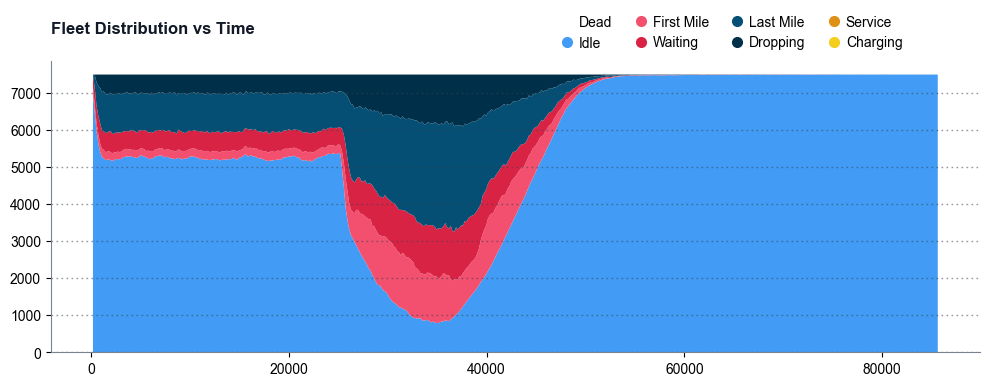

In [15]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(10, 4))
ax.stackplot(fleet_output.index, fleet_output.T,
             labels=[styles[c].label for c in fleet_output.columns],
             colors=[styles[c].color for c in fleet_output.columns])

handles = [
    Line2D([0], [0], marker="o", markersize=7,
           markerfacecolor=styles[c].color, markeredgecolor=styles[c].color, label=styles[c].label)
    for i, c in enumerate(fleet_output.columns)
]
ax.legend(handles=handles, bbox_to_anchor=(0.93, 1.2), ncol=4, frameon=False, handlelength=0.1)

style_plot(ax, title="Fleet Distribution vs Time")
plt.show()

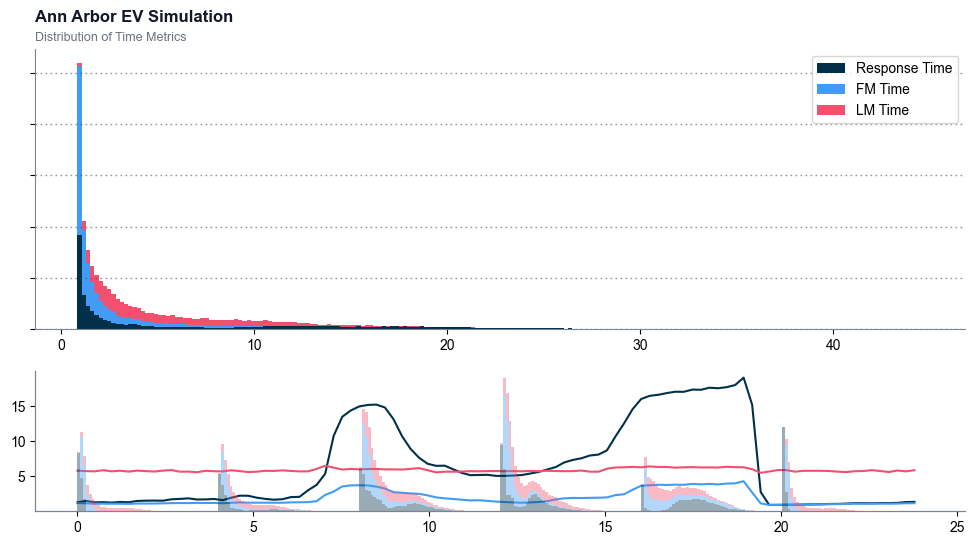

In [67]:
plot_evolving_histograms(output[["response_time", "fm_time", "lm_time"]] / 60, output["start_at"] / 3600, styles,
                         title="Ann Arbor EV Simulation", k=6, subtitle="Distribution of Time Metrics")

# Response Time (request time -> pickup time)
# FM - first mile (previous drop -> pickup time)
# LM - last mile (pickup -> drop time)

# + 4 minutes for pickup/drop

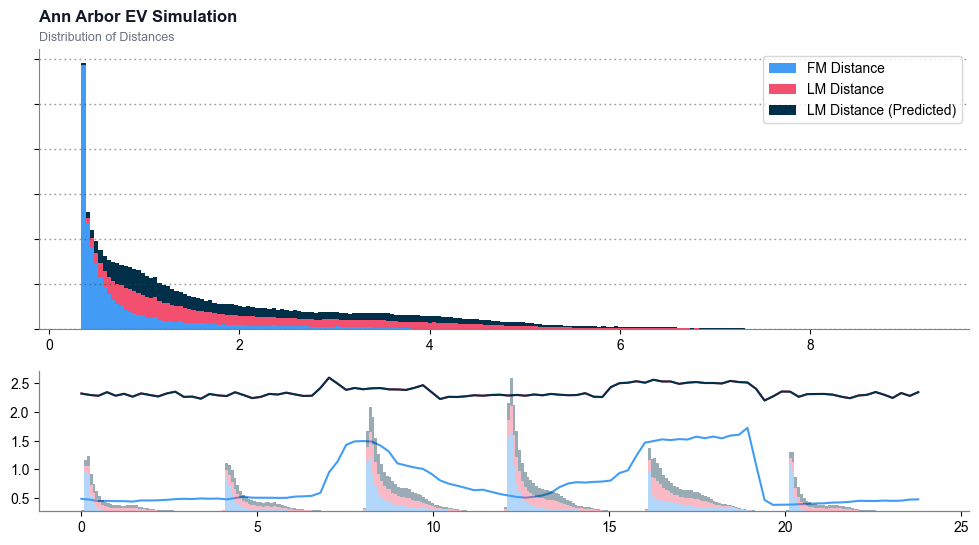

In [68]:
plot_evolving_histograms(output[["fm_dist", "lm_dist", "predicted_lm_dist"]] / 1.68, output["start_at"] / 3600, styles,
                         title="Ann Arbor EV Simulation", subtitle="Distribution of Distances", k=6)